# 02 Warmup Continuation Pattern Probe

This notebook tests lightweight continuation-training patterns that start from an existing DQA/FedSTO warmup checkpoint. The goal is to answer a practical question from the current DQA results: if the warmup model is already stronger than later federated rounds, which extra-training choices can improve mAP instead of degrading it?

The notebook writes only under `dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/`. It does not modify the main DQA or FedSTO experiment folders.

The default probes focus on fast supervised server continuation because the current failure mode points to noisy pseudo-label client updates. Optional client pseudo-label stress probes are included but disabled by default.

## 1. Experiment knobs

Change `SOURCE_WARMUP_KEY` to test a different warmup checkpoint. The default uses the scene-DQA warmup because it was one of the recent 12h runs and is representative of the issue.

In [1]:
print("Hello, World!")

Hello, World!


In [2]:
from __future__ import annotations

import json
import os
import random
import re
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path

import pandas as pd
import yaml

try:
    import matplotlib.pyplot as plt
except Exception:  # plotting is useful, but not required for running the probes
    plt = None

ROOT = Path.cwd().resolve()
while ROOT.name != "Object_Detection" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "Object_Detection":
    raise RuntimeError("Run this notebook from somewhere inside /app/Object_Detection")

DQA_ROOT = ROOT / "dynamic_quality_aware_classwise_aggregation"
NAV_ROOT = ROOT / "navigating_data_heterogeneity"
ET_ROOT = NAV_ROOT / "vendor" / "efficientteacher"
EXP_ROOT = DQA_ROOT / "exploring" / "runs" / "02_warmup_continuation_patterns"
FULL_LIST_ROOT = EXP_ROOT / "data_lists_full"
MINI_LIST_ROOT = EXP_ROOT / "mini_lists"
CONFIG_ROOT = EXP_ROOT / "configs"
RUN_ROOT = EXP_ROOT / "runs"
VAL_RUN_ROOT = EXP_ROOT / "val_runs"
RESULT_ROOT = EXP_ROOT / "results"

AVAILABLE_WARMUPS = {
    "dqa_corrected_12h": DQA_ROOT / "efficientteacher_dqa_cwa_corrected_12h" / "global_checkpoints" / "round000_warmup.pt",
    "dqa_v2_weather": DQA_ROOT / "efficientteacher_dqa_ver2" / "global_checkpoints" / "round000_warmup.pt",
    "dqa_v2_scene_12h": DQA_ROOT / "efficientteacher_dqa_ver2_scene_12h" / "global_checkpoints" / "round000_warmup.pt",
}

SOURCE_WARMUP_KEY = "dqa_v2_scene_12h"
WARMUP_CKPT = AVAILABLE_WARMUPS[SOURCE_WARMUP_KEY]

# Keep these small for quick iteration. Increase them after a pattern looks promising.
MINI_SERVER_TRAIN = 1024
MINI_SERVER_VAL = 512
MINI_TARGET_PER_CLIENT = 1024

# Use a CLI device for val.py, but keep YAML cfg.device empty.
# YACS literal-evaluates YAML strings like '0' into int 0, which causes a type mismatch
# against EfficientTeacher's default cfg.device='' during merge_from_file().
DEVICE_CLI = "0"
CONFIG_DEVICE = ""
IMG_SIZE = 640
BATCH_SIZE = 8
VAL_BATCH_SIZE = 1  # direct val.py has no workers flag; batch 1 reduces /dev/shm pressure
WORKERS = 0
SEED = 20260429

RUN_BASELINE_VAL = True
RUN_TRAINING = True
RUN_CLIENT_PSEUDO_PROBES = False
FORCE_RERUN = False
SKIP_AFTER_TRAIN_BEST_VAL = True

for path in [EXP_ROOT, FULL_LIST_ROOT, MINI_LIST_ROOT, CONFIG_ROOT, RUN_ROOT, VAL_RUN_ROOT, RESULT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

print(f"root: {ROOT}")
print(f"experiment root: {EXP_ROOT}")
print(f"warmup: {WARMUP_CKPT}")
assert WARMUP_CKPT.exists(), WARMUP_CKPT

root: /app/Object_Detection
experiment root: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns
warmup: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/efficientteacher_dqa_ver2_scene_12h/global_checkpoints/round000_warmup.pt


## 2. Patterns

The server-only patterns are intentionally conservative. They test whether mAP can recover by continuing from warmup without adding pseudo-label noise. The optional pseudo-label probes test whether stricter thresholds reduce the degradation seen in DQA/FedSTO rounds.

In [3]:
SERVER_PATTERNS = [
    {
        "name": "server_all_lr1e-3_ep2",
        "kind": "server_supervised",
        "epochs": 2,
        "lr0": 1e-3,
        "train_scope": "all",
        "weight_decay": 5e-4,
        "note": "Small LR full-model continuation from warmup.",
    },
    {
        "name": "server_all_lr3e-4_ep3",
        "kind": "server_supervised",
        "epochs": 3,
        "lr0": 3e-4,
        "train_scope": "all",
        "weight_decay": 5e-4,
        "note": "Even smaller LR to avoid moving away from a good warmup basin.",
    },
    {
        "name": "server_non_backbone_lr1e-3_ep3",
        "kind": "server_supervised",
        "epochs": 3,
        "lr0": 1e-3,
        "train_scope": "non_backbone",
        "weight_decay": 5e-4,
        "note": "Freeze backbone-like parameters; update neck/head side only.",
    },
    {
        "name": "server_neck_head_lr1e-3_ep3",
        "kind": "server_supervised",
        "epochs": 3,
        "lr0": 1e-3,
        "train_scope": "neck_head",
        "weight_decay": 5e-4,
        "note": "Detection-head-oriented update; useful if pseudo rounds damaged class/objectness heads.",
    },
    {
        "name": "server_backbone_lr5e-4_ep3",
        "kind": "server_supervised",
        "epochs": 3,
        "lr0": 5e-4,
        "train_scope": "backbone",
        "weight_decay": 5e-4,
        "note": "Backbone-only update, matching the FedSTO client-scope idea without pseudo labels.",
    },
    {
        "name": "server_all_lowwd_lr1e-3_ep2",
        "kind": "server_supervised",
        "epochs": 2,
        "lr0": 1e-3,
        "train_scope": "all",
        "weight_decay": 1e-4,
        "note": "Same as small-LR full update, but with lower weight decay.",
    },
]

CLIENT_PSEUDO_PATTERNS = [
    {
        "name": "client0_default_ssod_backbone_ep1",
        "kind": "client_pseudo_probe",
        "client_id": 0,
        "epochs": 1,
        "lr0": 1e-3,
        "train_scope": "backbone",
        "ssod_overrides": {},
        "note": "Default EfficientTeacher/FedSTO pseudo-label thresholds; expected to expose the degradation mode.",
    },
    {
        "name": "client0_strict_ssod_backbone_ep1",
        "kind": "client_pseudo_probe",
        "client_id": 0,
        "epochs": 1,
        "lr0": 1e-3,
        "train_scope": "backbone",
        "ssod_overrides": {
            "nms_conf_thres": 0.35,
            "ignore_thres_low": 0.35,
            "ignore_thres_high": 0.75,
            "teacher_loss_weight": 0.5,
            "box_loss_weight": 0.03,
            "obj_loss_weight": 0.5,
        },
        "note": "Stricter pseudo labels and lower teacher loss; tests whether noisy low-confidence labels are the blocker.",
    },
]

print(f"server patterns: {len(SERVER_PATTERNS)}")
print(f"optional client pseudo probes: {len(CLIENT_PSEUDO_PATTERNS)}")

server patterns: 6
optional client pseudo probes: 2


## 3. Helpers

In [4]:
def read_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def sample_list(src: Path, dst: Path, limit: int, *, seed: int) -> Path:
    lines = read_lines(src)
    rng = random.Random(seed)
    rng.shuffle(lines)
    keep = lines[: min(limit, len(lines))]
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.write_text("\n".join(keep) + "\n", encoding="utf-8")
    return dst


def run_command(cmd: list[str], *, cwd: Path, log_path: Path | None = None) -> subprocess.CompletedProcess:
    env = os.environ.copy()
    env.setdefault("WANDB_DISABLED", "true")
    env.setdefault("MPLBACKEND", "Agg")
    if SKIP_AFTER_TRAIN_BEST_VAL:
        env["ET_SKIP_AFTER_TRAIN_BEST_VAL"] = "1"
    print(" ".join(str(x) for x in cmd))
    proc = subprocess.run(
        cmd,
        cwd=str(cwd),
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if log_path is not None:
        log_path.parent.mkdir(parents=True, exist_ok=True)
        log_path.write_text(proc.stdout, encoding="utf-8")
    print(proc.stdout[-4000:])
    proc.check_returncode()
    return proc


def run_dir_for(name: str) -> Path:
    return RUN_ROOT / name


def best_weight_for(name: str) -> Path | None:
    weight_dir = run_dir_for(name) / "weights"
    for candidate in [weight_dir / "best.pt", weight_dir / "last.pt"]:
        if candidate.exists():
            return candidate
    return None


def parse_results_csv(results_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(results_csv)
    df.columns = [str(c).strip() for c in df.columns]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")
    return df


def summarize_train_run(pattern: dict) -> dict:
    name = pattern["name"]
    results_csv = run_dir_for(name) / "results.csv"
    row = {
        "name": name,
        "kind": pattern.get("kind", "train"),
        "status": "missing_results",
        "epochs": pattern.get("epochs"),
        "lr0": pattern.get("lr0"),
        "train_scope": pattern.get("train_scope"),
        "weight_decay": pattern.get("weight_decay"),
        "note": pattern.get("note", ""),
        "run_dir": str(run_dir_for(name)),
    }
    if not results_csv.exists():
        return row
    df = parse_results_csv(results_csv)
    map_col = "metrics/mAP_0.5:0.95"
    map50_col = "metrics/mAP_0.5"
    precision_col = "metrics/precision"
    recall_col = "metrics/recall"
    best_idx = df[map_col].astype(float).idxmax()
    best = df.loc[best_idx]
    final = df.iloc[-1]
    row.update(
        {
            "status": "ok",
            "best_epoch": int(best.get("epoch", best_idx)),
            "map50_best": float(best[map50_col]),
            "map50_95_best": float(best[map_col]),
            "precision_best": float(best[precision_col]),
            "recall_best": float(best[recall_col]),
            "map50_final": float(final[map50_col]),
            "map50_95_final": float(final[map_col]),
            "precision_final": float(final[precision_col]),
            "recall_final": float(final[recall_col]),
            "results_csv": str(results_csv),
            "best_weight": str(best_weight_for(name) or ""),
        }
    )
    return row


def parse_val_stdout(stdout: str) -> dict:
    metric_line = None
    for line in stdout.splitlines():
        if line.strip().startswith("all"):
            metric_line = line.strip()
    if metric_line is None:
        raise RuntimeError("Could not find the 'all' metrics row in val.py output")
    parts = re.split(r"\s+", metric_line)
    return {
        "images": int(float(parts[1])),
        "labels": int(float(parts[2])),
        "precision_final": float(parts[-4]),
        "recall_final": float(parts[-3]),
        "map50_final": float(parts[-2]),
        "map50_95_final": float(parts[-1]),
    }


def write_yaml(path: Path, data: dict) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(yaml.safe_dump(data, sort_keys=False, allow_unicode=True), encoding="utf-8")
    return path

## 4. Build isolated mini lists and configs

In [5]:
sys.path.insert(0, str(NAV_ROOT))
import setup_fedsto_exact_reproduction as setup

# Redirect the setup helper to this notebook's isolated workspace.
setup.WORK_ROOT = EXP_ROOT
setup.LIST_ROOT = FULL_LIST_ROOT
setup.CONFIG_ROOT = CONFIG_ROOT
setup.RUN_ROOT = RUN_ROOT
setup.ET_ROOT = ET_ROOT

manifest = setup.build_data_lists()

MINI_SERVER_TRAIN_LIST = sample_list(
    FULL_LIST_ROOT / "server_cloudy_train.txt",
    MINI_LIST_ROOT / f"server_cloudy_train_{MINI_SERVER_TRAIN}.txt",
    MINI_SERVER_TRAIN,
    seed=SEED,
)
MINI_SERVER_VAL_LIST = sample_list(
    FULL_LIST_ROOT / "server_cloudy_val.txt",
    MINI_LIST_ROOT / f"server_cloudy_val_{MINI_SERVER_VAL}.txt",
    MINI_SERVER_VAL,
    seed=SEED + 1,
)

MINI_TARGET_LISTS = {}
for client in setup.CLIENTS:
    src = FULL_LIST_ROOT / f"client_{client['id']}_{client['weather']}_target.txt"
    dst = MINI_LIST_ROOT / f"client_{client['id']}_{client['weather']}_target_{MINI_TARGET_PER_CLIENT}.txt"
    MINI_TARGET_LISTS[client["id"]] = sample_list(src, dst, MINI_TARGET_PER_CLIENT, seed=SEED + 10 + client["id"])

print("mini server train:", MINI_SERVER_TRAIN_LIST, len(read_lines(MINI_SERVER_TRAIN_LIST)))
print("mini server val:", MINI_SERVER_VAL_LIST, len(read_lines(MINI_SERVER_VAL_LIST)))
for cid, path in MINI_TARGET_LISTS.items():
    print(f"mini target client {cid}:", path, len(read_lines(path)))

mini server train: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/mini_lists/server_cloudy_train_1024.txt 1024
mini server val: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/mini_lists/server_cloudy_val_512.txt 512
mini target client 0: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/mini_lists/client_0_overcast_target_1024.txt 1024
mini target client 1: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/mini_lists/client_1_rainy_target_1024.txt 1024
mini target client 2: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/mini_lists/client_2_snowy_target_1024.txt 1024


In [6]:
def make_config_for_pattern(pattern: dict) -> Path:
    target = None
    if pattern.get("kind") == "client_pseudo_probe":
        target = MINI_TARGET_LISTS[pattern["client_id"]]

    cfg = setup.efficientteacher_config(
        name=pattern["name"],
        train=MINI_SERVER_TRAIN_LIST,
        val=MINI_SERVER_VAL_LIST,
        target=target,
        weights=str(WARMUP_CKPT.resolve()),
        epochs=int(pattern["epochs"]),
        train_scope=pattern.get("train_scope", "all"),
        orthogonal_weight=float(pattern.get("orthogonal_weight", 0.0)),
        batch_size=BATCH_SIZE,
        workers=WORKERS,
        device=CONFIG_DEVICE,
    )
    cfg["project"] = str(RUN_ROOT.resolve())
    cfg["exist_ok"] = True
    cfg["Dataset"]["img_size"] = IMG_SIZE
    cfg["Dataset"]["workers"] = WORKERS
    cfg["hyp"]["lr0"] = float(pattern.get("lr0", cfg["hyp"]["lr0"]))
    cfg["hyp"]["lrf"] = float(pattern.get("lrf", 1.0))
    cfg["hyp"]["weight_decay"] = float(pattern.get("weight_decay", cfg["hyp"]["weight_decay"]))
    cfg["hyp"]["warmup_epochs"] = int(pattern.get("warmup_epochs", 0))

    # Keep continuation stable; large synthetic jumps make it harder to identify real gains.
    if pattern.get("kind") == "server_supervised":
        cfg["SSOD"] = {"train_domain": False}

    for key, value in pattern.get("ssod_overrides", {}).items():
        cfg["SSOD"][key] = value

    return setup.write_config(f"{pattern['name']}.yaml", cfg)


VAL_CFG = setup.efficientteacher_config(
    name="warmup_eval_same_mini_cfg",
    train=MINI_SERVER_TRAIN_LIST,
    val=MINI_SERVER_VAL_LIST,
    target=None,
    weights=str(WARMUP_CKPT.resolve()),
    epochs=1,
    train_scope="all",
    batch_size=VAL_BATCH_SIZE,
    workers=WORKERS,
    device=CONFIG_DEVICE,
)
VAL_CFG["Dataset"]["img_size"] = IMG_SIZE
VAL_CFG_PATH = write_yaml(CONFIG_ROOT / "warmup_eval_same_mini.yaml", VAL_CFG)

CONFIG_PATHS = {p["name"]: make_config_for_pattern(p) for p in SERVER_PATTERNS}
if RUN_CLIENT_PSEUDO_PROBES:
    CONFIG_PATHS.update({p["name"]: make_config_for_pattern(p) for p in CLIENT_PSEUDO_PATTERNS})

for name, path in CONFIG_PATHS.items():
    print(name, "->", path)

server_all_lr1e-3_ep2 -> /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/configs/server_all_lr1e-3_ep2.yaml
server_all_lr3e-4_ep3 -> /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/configs/server_all_lr3e-4_ep3.yaml
server_non_backbone_lr1e-3_ep3 -> /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/configs/server_non_backbone_lr1e-3_ep3.yaml
server_neck_head_lr1e-3_ep3 -> /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/configs/server_neck_head_lr1e-3_ep3.yaml
server_backbone_lr5e-4_ep3 -> /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/configs/server_backbone_lr5e-4_ep3.yaml
server_all_lowwd_lr1e-3_ep2 -> /app/Object_Detection/dynamic_quality_aware_classwise_aggregatio

## 5. Baseline warmup evaluation

This evaluates the untouched warmup checkpoint on the same mini validation list used by all continuation runs. `VAL_BATCH_SIZE=1` keeps shared-memory use low.

In [7]:
BASELINE_JSON = RESULT_ROOT / "warmup_eval_same_mini.json"

if RUN_BASELINE_VAL and (FORCE_RERUN or not BASELINE_JSON.exists()):
    baseline_log = VAL_RUN_ROOT / "warmup_eval_same_mini_stdout.txt"
    cmd = [
        sys.executable,
        "val.py",
        "--weights",
        str(WARMUP_CKPT.resolve()),
        "--batch-size",
        str(VAL_BATCH_SIZE),
        "--imgsz",
        str(IMG_SIZE),
        "--device",
        DEVICE_CLI,
        "--project",
        str(VAL_RUN_ROOT.resolve()),
        "--name",
        "warmup_eval_same_mini",
        "--exist-ok",
        "--no-plots",
        "--cfg",
        str(VAL_CFG_PATH.resolve()),
    ]
    proc = run_command(cmd, cwd=ET_ROOT, log_path=baseline_log)
    baseline = parse_val_stdout(proc.stdout)
    baseline.update(
        {
            "name": "warmup_eval_same_mini",
            "kind": "baseline_eval",
            "status": "ok",
            "warmup_key": SOURCE_WARMUP_KEY,
            "checkpoint": str(WARMUP_CKPT),
            "log": str(baseline_log),
        }
    )
    BASELINE_JSON.write_text(json.dumps(baseline, indent=2), encoding="utf-8")
elif BASELINE_JSON.exists():
    baseline = json.loads(BASELINE_JSON.read_text(encoding="utf-8"))
else:
    baseline = {"name": "warmup_eval_same_mini", "kind": "baseline_eval", "status": "skipped"}

baseline

{'images': 512,
 'labels': 10082,
 'precision_final': 0.627,
 'recall_final': 0.41,
 'map50_final': 0.453,
 'map50_95_final': 0.26,
 'name': 'warmup_eval_same_mini',
 'kind': 'baseline_eval',
 'status': 'ok',
 'warmup_key': 'dqa_v2_scene_12h',
 'checkpoint': '/app/Object_Detection/dynamic_quality_aware_classwise_aggregation/efficientteacher_dqa_ver2_scene_12h/global_checkpoints/round000_warmup.pt',
 'log': '/app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/val_runs/warmup_eval_same_mini_stdout.txt'}

## 6. Run continuation patterns

In [8]:
patterns_to_run = list(SERVER_PATTERNS)
if RUN_CLIENT_PSEUDO_PROBES:
    patterns_to_run += CLIENT_PSEUDO_PATTERNS

for pattern in patterns_to_run:
    name = pattern["name"]
    results_csv = run_dir_for(name) / "results.csv"
    if results_csv.exists() and not FORCE_RERUN:
        print(f"skip existing: {name}")
        continue
    if not RUN_TRAINING:
        print(f"dry skip: {name}")
        continue
    if FORCE_RERUN and run_dir_for(name).exists():
        shutil.rmtree(run_dir_for(name))
    log_path = RESULT_ROOT / "logs" / f"{name}.txt"
    cmd = [sys.executable, "train.py", "--cfg", str(CONFIG_PATHS[name].resolve())]
    run_command(cmd, cwd=ET_ROOT, log_path=log_path)

skip existing: server_all_lr1e-3_ep2
/root/micromamba/envs/al_yolov8/bin/python train.py --cfg /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/configs/server_all_lr3e-4_ep3.yaml
        P          R     mAP@.5 mAP@.5:.95:  34%|███▍      | 11/32 [00:01<00:02,  8.38it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95:  38%|███▊      | 12/32 [00:01<00:02,  8.43it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95:  41%|████      | 13/32 [00:01<00:02,  8.46it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95:  44%|████▍     | 14/32 [00:01<00:02,  8.46it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95:  47%|████▋     | 15/32 [00:01<00:01,  8.52it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95:  50%|█████     | 16/32 [00:01<00:

## 7. Summarize mAP and related metrics

In [9]:
rows = []
if BASELINE_JSON.exists():
    rows.append(json.loads(BASELINE_JSON.read_text(encoding="utf-8")))
else:
    rows.append(baseline)

for pattern in patterns_to_run:
    rows.append(summarize_train_run(pattern))

summary = pd.DataFrame(rows)

if "map50_95_final" in summary.columns and (summary["name"] == "warmup_eval_same_mini").any():
    base_value = summary.loc[summary["name"] == "warmup_eval_same_mini", "map50_95_final"].dropna()
    if len(base_value):
        base_map = float(base_value.iloc[0])
        summary["delta_map50_95_vs_warmup"] = summary["map50_95_final"] - base_map
        summary["delta_map50_vs_warmup"] = summary["map50_final"] - float(summary.loc[summary["name"] == "warmup_eval_same_mini", "map50_final"].iloc[0])

summary_path = RESULT_ROOT / "continuation_summary.csv"
summary.to_csv(summary_path, index=False)
print("saved:", summary_path)

display_columns = [
    "name",
    "kind",
    "status",
    "epochs",
    "lr0",
    "train_scope",
    "map50_final",
    "map50_95_final",
    "delta_map50_95_vs_warmup",
    "precision_final",
    "recall_final",
    "map50_95_best",
    "best_epoch",
    "note",
]
display_columns = [c for c in display_columns if c in summary.columns]
summary[display_columns].sort_values("map50_95_final", ascending=False, na_position="last")

saved: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/results/continuation_summary.csv


,name,kind,status,epochs,lr0,train_scope,map50_final,map50_95_final,delta_map50_95_vs_warmup,precision_final,recall_final,map50_95_best,best_epoch,note
2,server_all_lr3e-4_ep3,server_supervised,ok,3.0,0.0003,all,0.46800,0.27098,0.01098,0.64479,0.41247,0.27098,2.0,Even smaller LR to avoid moving away from a go...
1,server_all_lr1e-3_ep2,server_supervised,ok,2.0,0.0010,all,0.46212,0.26938,0.00938,0.63590,0.41226,0.26938,1.0,Small LR full-model continuation from warmup.
6,server_all_lowwd_lr1e-3_ep2,server_supervised,ok,2.0,0.0010,all,0.46199,0.26915,0.00915,0.62248,0.41992,0.26915,1.0,"Same as small-LR full update, but with lower w..."
4,server_neck_head_lr1e-3_ep3,server_supervised,ok,3.0,0.0010,neck_head,0.46464,0.26771,0.00771,0.57404,0.46848,0.26771,2.0,Detection-head-oriented update; useful if pseu...
3,server_non_backbone_lr1e-3_ep3,server_supervised,ok,3.0,0.0010,non_backbone,0.46364,0.26700,0.00700,0.57265,0.46746,0.26712,1.0,Freeze backbone-like parameters; update neck/h...
5,server_backbone_lr5e-4_ep3,server_supervised,ok,3.0,0.0005,backbone,0.46582,0.26576,0.00576,0.62216,0.42752,0.26576,2.0,"Backbone-only update, matching the FedSTO clie..."
0,warmup_eval_same_mini,baseline_eval,ok,NaN,NaN,NaN,0.45300,0.26000,0.00000,0.62700,0.41000,NaN,NaN,NaN


saved: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/exploring/runs/02_warmup_continuation_patterns/results/continuation_map_bars.png


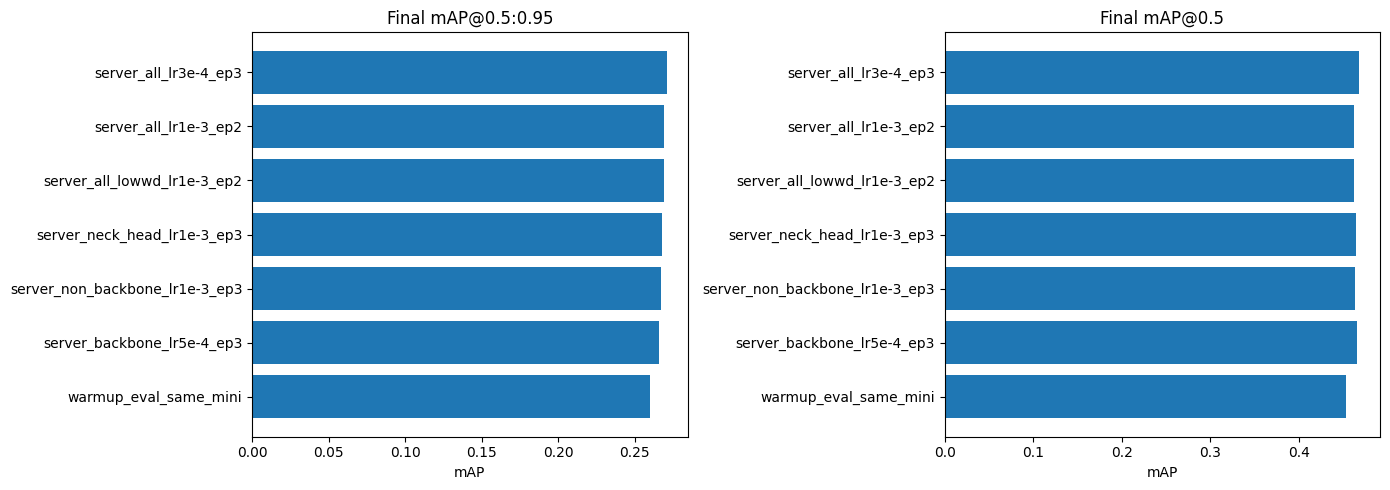

In [10]:
if plt is not None and "map50_95_final" in summary.columns:
    plot_df = summary[summary["status"].eq("ok")].copy()
    plot_df = plot_df.sort_values("map50_95_final", ascending=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(plot_df["name"], plot_df["map50_95_final"])
    axes[0].set_title("Final mAP@0.5:0.95")
    axes[0].set_xlabel("mAP")
    axes[1].barh(plot_df["name"], plot_df["map50_final"])
    axes[1].set_title("Final mAP@0.5")
    axes[1].set_xlabel("mAP")
    fig.tight_layout()
    figure_path = RESULT_ROOT / "continuation_map_bars.png"
    fig.savefig(figure_path, dpi=160)
    print("saved:", figure_path)
else:
    print("matplotlib unavailable or no completed metrics yet")

## 8. Reading the result

Use the summary as a decision table:

- If a server-only pattern beats the warmup baseline, the current issue is likely not a hard ceiling of the warmup model. It means the later DQA/FedSTO pseudo-label updates are pulling the model away from a better supervised solution.
- If `neck_head` or `non_backbone` beats `all`, future DQA phase-2 should avoid full-model drift and should apply a stronger server anchor or update only the detection side.
- If low LR beats higher LR, the warmup checkpoint should be treated as a strong initialization and phase-2 should use smaller client/server update magnitudes.
- If the optional strict SSOD probe beats default SSOD, the low pseudo-label thresholds are likely too permissive. That matches the observed class imbalance and near-zero train-class coverage for rare classes.
- If nothing beats warmup on the same mini validation, the safest next step is not more federated rounds. Re-check validation split consistency, warmup overfitting, and direct full-split evaluation first.